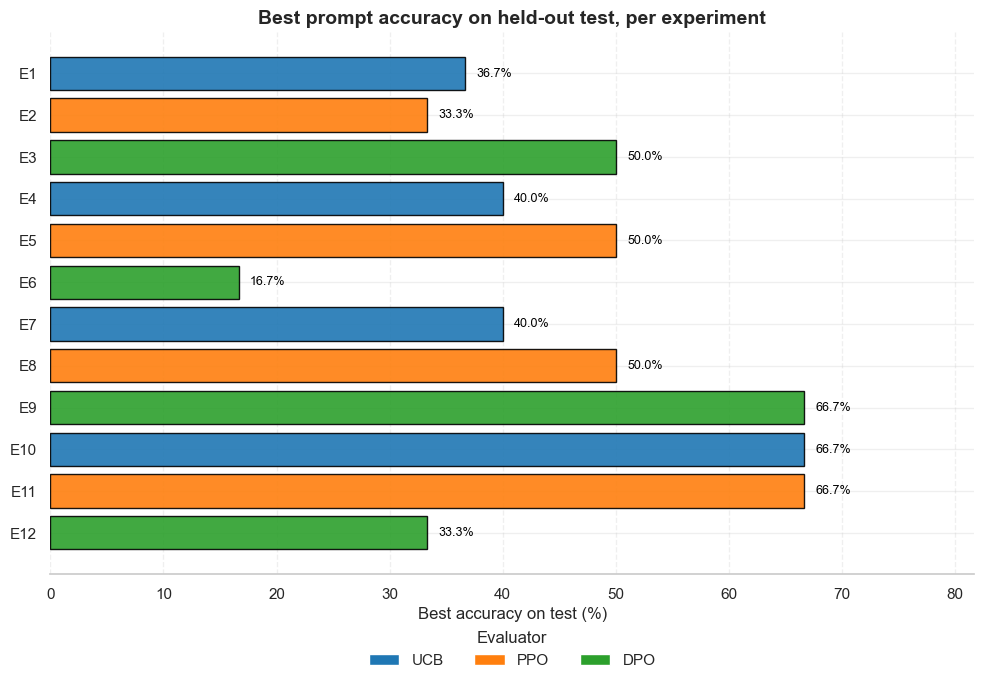

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from pathlib import Path


# ---- Data ----
data = [
    ("E1","UCB", 48, 1, "4", 36.67),
    ("E2","PPO", 48, 1, "2", 33.33),
    ("E3","DPO", 48, 1, "1", 50.00),
    ("E4","UCB",288, 2, "2", 40.00),
    ("E5","PPO",288, 2, "2", 50.00),
    ("E6","DPO",288, 2, "2", 16.67),
    ("E7","UCB",648, 2, "5", 40.00),
    ("E8","PPO",648, 2, "2–3", 50.00),
    ("E9","DPO",648, 2, "1", 66.67),
    ("E10","UCB",1536,3,"4", 66.67),
    ("E11","PPO",1536,3,"2", 66.67),
    ("E12","DPO",1536,3,"2", 33.33),
]

df = pd.DataFrame(data, columns=["Run","Evaluator","Budget","K","BestRound","BestAccuracy"])

# Order by run number
df["RunNum"] = df["Run"].str.extract(r"E(\d+)").astype(int)
df = df.sort_values("RunNum", ascending=True)

# ---- Plot ----
color_map = {"UCB": "#1f77b4", "PPO": "#ff7f0e", "DPO": "#2ca02c"}
colors = [color_map[e] for e in df["Evaluator"]]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(df["Run"], df["BestAccuracy"], color=colors, alpha=0.9, edgecolor="black")

# Annotations at the end of bars
for bar, val in zip(bars, df["BestAccuracy"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(x + 1, y, f"{val:.1f}%", va="center", ha="left", fontsize=9, color="black")

# Aesthetics
ax.set_xlabel("Best accuracy on test (%)", fontsize=12)
ax.set_ylabel("")
ax.set_title("Best prompt accuracy on held-out test, per experiment", fontsize=14, weight="bold")
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.set_xlim(0, max(df["BestAccuracy"]) + 15)

# Put E1 at the top
ax.invert_yaxis()

# Remove spines for a cleaner look
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Legend for colors below the plot
legend_handles = [Patch(facecolor=color_map[k], label=k) for k in color_map]
ax.legend(handles=legend_handles, title="Evaluator", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.08), ncol=3)

plt.tight_layout()







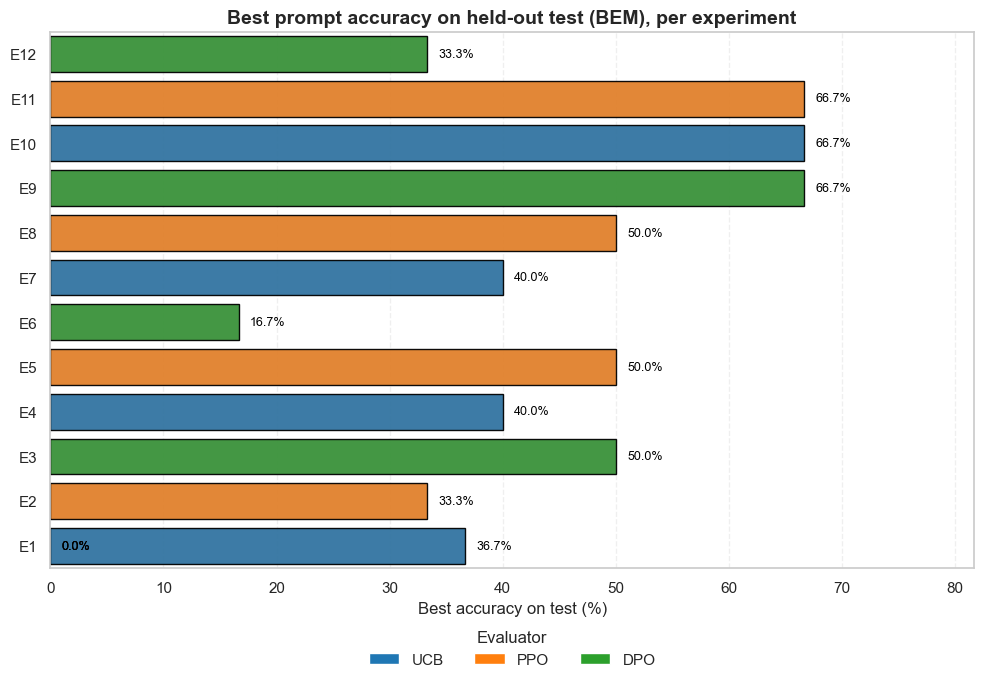

In [5]:
import seaborn as sns




# Order by run number
df["RunNum"] = df["Run"].str.extract(r"E(\d+)").astype(int)
df = df.sort_values("RunNum", ascending=True)

# ---- Seaborn style/theme ----
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "grid.alpha": 0.3
})


# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 7))

# dodge=False => one bar per Run (colored by its Evaluator)
sns.barplot(
    data=df,
    y="Run",
    x="BestAccuracy",
    hue="Evaluator",
    order=df["Run"],
    palette=color_map,
    dodge=False,
    edgecolor="black",
    alpha=0.95,
    ax=ax
)

# Annotations at the end of bars
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height()/2
    ax.text(width + 1, y, f"{width:.1f}%", va="center", ha="left", fontsize=9, color="black")

# Aesthetics
ax.set_xlabel("Best accuracy on test (%)", fontsize=12)
ax.set_ylabel("")
ax.set_title("Best prompt accuracy on held-out test (BEM), per experiment", fontsize=14, weight="bold")
ax.set_xlim(0, df["BestAccuracy"].max() + 15)
ax.invert_yaxis()  # put E1 at the top
ax.grid(axis="x", linestyle="--")

# Legend below the plot (custom handles to ensure order)
legend_handles = [Patch(facecolor=color_map[k], label=k) for k in ["UCB", "PPO", "DPO"]]
leg = ax.legend(
    handles=legend_handles,
    title="Evaluator",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.09),
    ncol=3
)

plt.tight_layout()
plt.show()


TypeError: can only concatenate str (not "float") to str

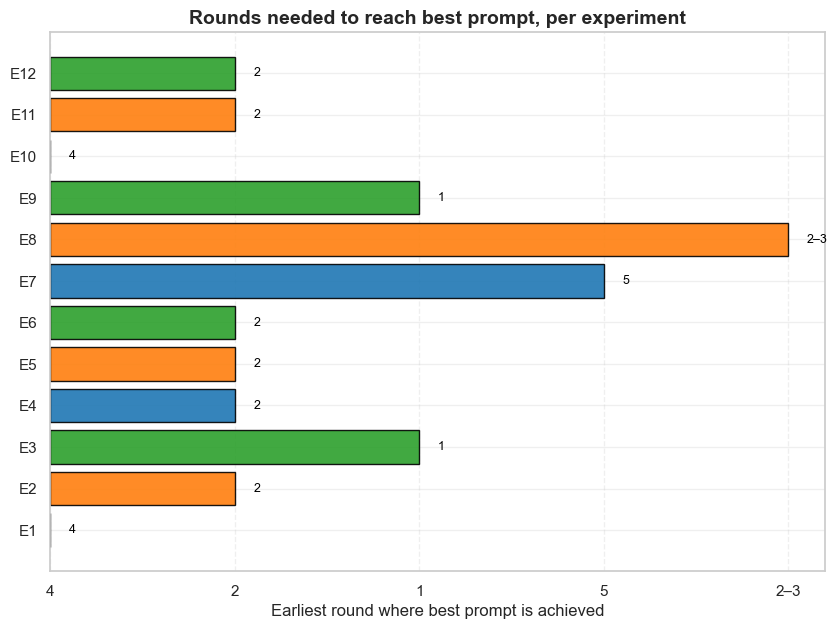

In [6]:
def earliest_round(s: str) -> int:
    s = s.replace("–", "-")
    return int(s.split("-")[0])


# Order by run number
df["RunNum"] = df["Run"].str.extract(r"E(\d+)").astype(int)
df = df.sort_values("RunNum", ascending=True)

# ---- Style to match the provided chart ----
color_map = {"UCB": "#1f77b4", "PPO": "#ff7f0e", "DPO": "#2ca02c"}
colors = [color_map[e] for e in df["Evaluator"]]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(df["Run"], df["BestRound"], color=colors, alpha=0.9, edgecolor="black")

# Annotations at the end of bars (use the original text, e.g., "2–3")
for bar, txt in zip(bars, df["BestRound"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(x + 0.1, y, f"{txt}", va="center", ha="left", fontsize=9, color="black")

# Aesthetics consistent with the example
ax.set_xlabel("Earliest round where best prompt is achieved", fontsize=12)
ax.set_ylabel("")
ax.set_title("Rounds needed to reach best prompt, per experiment", fontsize=14, weight="bold")
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.set_xlim(0, max(df["BestRound"]) + 1.5)  # little headroom for annotations

# Put E1 at the top
ax.invert_yaxis()

# Remove spines for a cleaner look
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Legend for colors below the plot
legend_handles = [Patch(facecolor=color_map[k], label=k) for k in color_map]
ax.legend(handles=legend_handles, title="Evaluator", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.08), ncol=3)

plt.tight_layout()

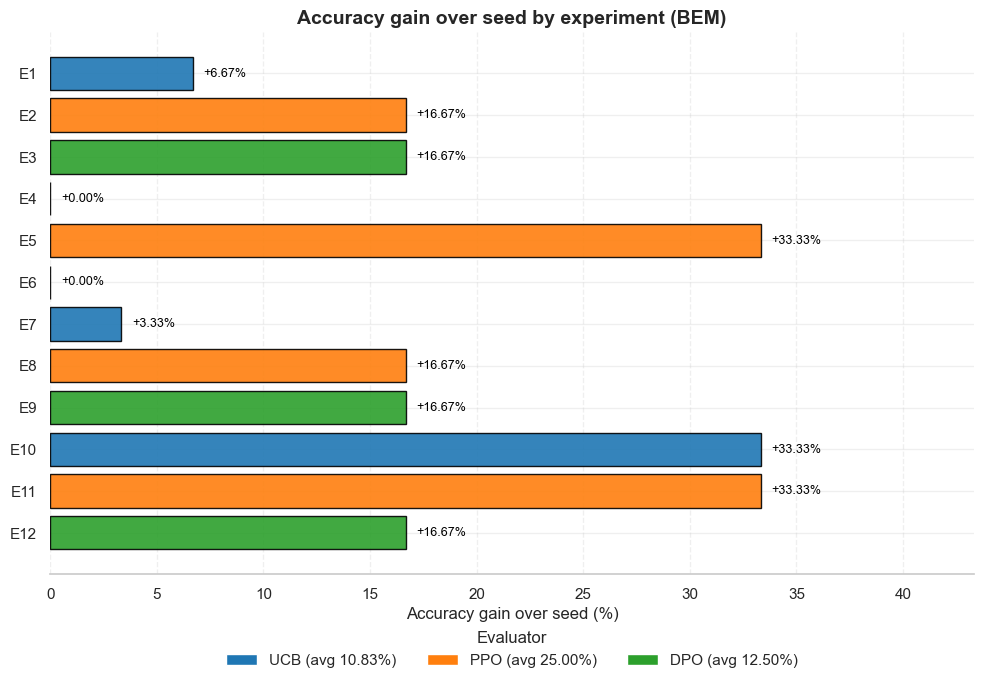

In [7]:

data_gains = [
    ("E1","UCB", 6.67),
    ("E2","PPO",16.67),
    ("E3","DPO",16.67),
    ("E4","UCB", 0.00),
    ("E5","PPO",33.33),
    ("E6","DPO", 0.00),
    ("E7","UCB", 3.33),
    ("E8","PPO",16.67),
    ("E9","DPO",16.67),
    ("E10","UCB",33.33),
    ("E11","PPO",33.33),
    ("E12","DPO",16.67),
]

df_gains = pd.DataFrame(data_gains, columns=["Run","Evaluator","GrowthPct"])
df_gains["RunNum"] = df_gains["Run"].str.extract(r"E(\d+)").astype(int)
df_gains = df_gains.sort_values("RunNum", ascending=True)

avg = df_gains.groupby("Evaluator", as_index=False)["GrowthPct"].mean()
avg_dict = dict(zip(avg["Evaluator"], avg["GrowthPct"]))

color_map = {"UCB": "#1f77b4", "PPO": "#ff7f0e", "DPO": "#2ca02c"}
colors = [color_map[e] for e in df_gains["Evaluator"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_gains["Run"], df_gains["GrowthPct"], color=colors, alpha=0.9, edgecolor="black")

for bar, val in zip(bars, df_gains["GrowthPct"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(x + 0.5, y, f"+{val:.2f}%", va="center", ha="left", fontsize=9, color="black")

ax.set_xlabel("Accuracy gain over seed (%)", fontsize=12)
ax.set_ylabel("")
ax.set_title("Accuracy gain over seed by experiment (BEM)", fontsize=14, weight="bold")
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.set_xlim(0, max(df_gains["GrowthPct"]) + 10)
ax.invert_yaxis()

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

legend_handles = [Patch(facecolor=color_map[k], label=f"{k} (avg {avg_dict[k]:.2f}%)") for k in ["UCB","PPO","DPO"]]
ax.legend(handles=legend_handles, title="Evaluator", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.08), ncol=3)

plt.tight_layout()

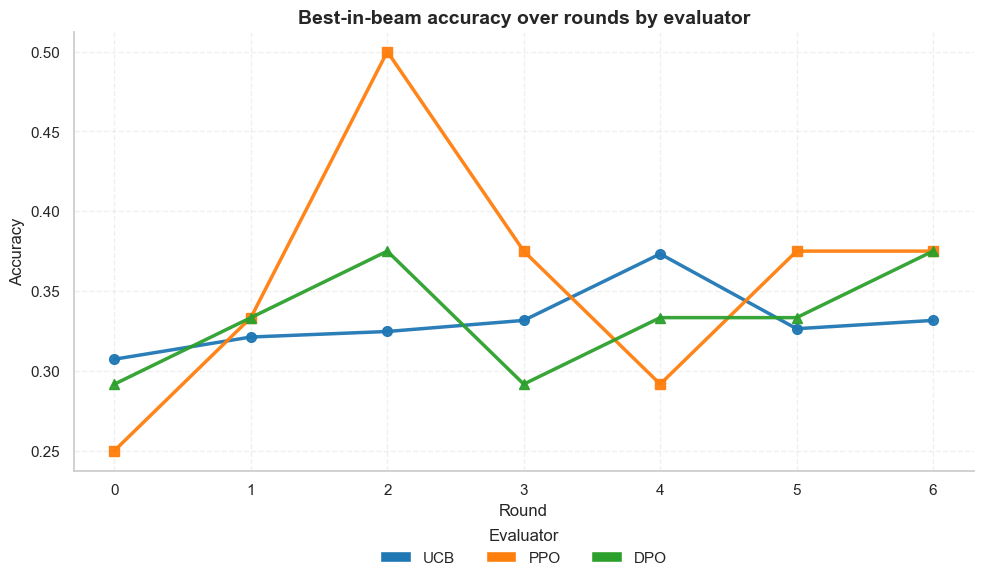

In [8]:
import json, re, pathlib, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch

log_path = pathlib.Path(r"C:\Users\cypri\Desktop\Master Thesis\exp\all logs")
lines = log_path.read_text(encoding="utf-8", errors="ignore").splitlines()
run_starts = [i for i,l in enumerate(lines) if l.strip().startswith("{")]

def parse_runs(lines, run_starts):
    runs = {}
    for si, start in enumerate(run_starts):
        end = run_starts[si+1] if si+1 < len(run_starts) else len(lines)
        meta = json.loads(lines[start])
        m = re.search(r"exp[\\/](E\d+)", meta.get("out","") or "")
        rid = m.group(1) if m else f"run_{si}"
        record = {"evaluator": meta.get("evaluator"), "rounds": [],
                  "samples_per_eval": meta.get("samples_per_eval"),
                  "eval_rounds": meta.get("eval_rounds"),
                  "eval_prompts_per_round": meta.get("eval_prompts_per_round"),
                  "top_k": meta.get("top_k"), "beam_size": meta.get("beam_size")}
        i = start + 1
        while i < end:
            l = lines[i].strip()
            if l.startswith("======== ROUND"):
                m2 = re.search(r"ROUND\s+(\d+)", l)
                rnum = int(m2.group(1)) if m2 else None
                # time
                if i+1 < end and re.match(r"([0-9]+(?:\.[0-9]+)?)s", lines[i+1].strip()):
                    i += 2
                else:
                    i += 1
                arrs = []
                while i < end and not lines[i].startswith("{") and not lines[i].startswith("======== ROUND"):
                    s = lines[i].strip()
                    if s.startswith("[") and s.endswith("]"):
                        try:
                            arrs.append(json.loads(s))
                        except Exception:
                            pass
                    i += 1
                record["rounds"].append({"round": rnum, "arrays": arrs})
                continue
            i += 1
        runs[rid] = record
    return runs

runs = parse_runs(lines, run_starts)

# Per-run series
per_run_series = {}
for rid, rec in runs.items():
    eval_name = rec["evaluator"]
    xs, ys = [], []
    for rr in sorted(rec["rounds"], key=lambda x: x["round"] if x["round"] is not None else -1):
        arrs = rr["arrays"]
        if not arrs:
            continue
        rewards = arrs[0] if eval_name == "ucb" else (arrs[1] if len(arrs) > 1 else [])
        if not rewards:
            continue
        xs.append(rr["round"])
        ys.append(max(rewards))
    if xs:
        per_run_series[rid] = {"evaluator": eval_name, "rounds": np.array(xs), "best": np.array(ys)}

# Aggregate by evaluator
all_rounds = sorted(set(int(r) for s in per_run_series.values() for r in s["rounds"]))
evals = ["ucb","ppo","dpo"]
agg = {e: {"rounds": [], "mean": []} for e in evals}

for e in evals:
    for r in all_rounds:
        vals = []
        for s in per_run_series.values():
            if s["evaluator"] != e: 
                continue
            mask = (s["rounds"] == r)
            if mask.any():
                vals.append(float(s["best"][mask][0]))
        if vals:
            agg[e]["rounds"].append(r)
            agg[e]["mean"].append(sum(vals)/len(vals))

# Plot
color_map = {"ucb": "#1f77b4", "ppo": "#ff7f0e", "dpo": "#2ca02c"}
marker_map = {"ucb": "o", "ppo": "s", "dpo": "^"}

fig, ax = plt.subplots(figsize=(10, 6))

for e in evals:
    rs = agg[e]["rounds"]
    ms = agg[e]["mean"]
    if not rs:
        continue
    ax.plot(rs, ms, marker=marker_map[e], linewidth=2.5, markersize=7,
            label=e.upper(), color=color_map[e], alpha=0.95)

ax.set_title("Best-in-beam accuracy over rounds by evaluator", fontsize=14, weight="bold")
ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.grid(True, axis="both", alpha=0.3, linestyle="--")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

legend_handles = [Patch(facecolor=color_map[k], label=k.upper()) for k in evals]
ax.legend(handles=legend_handles, title="Evaluator", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.10), ncol=3)

plt.tight_layout()

OSError: Cannot save file into a non-existent directory: '\mnt\data'

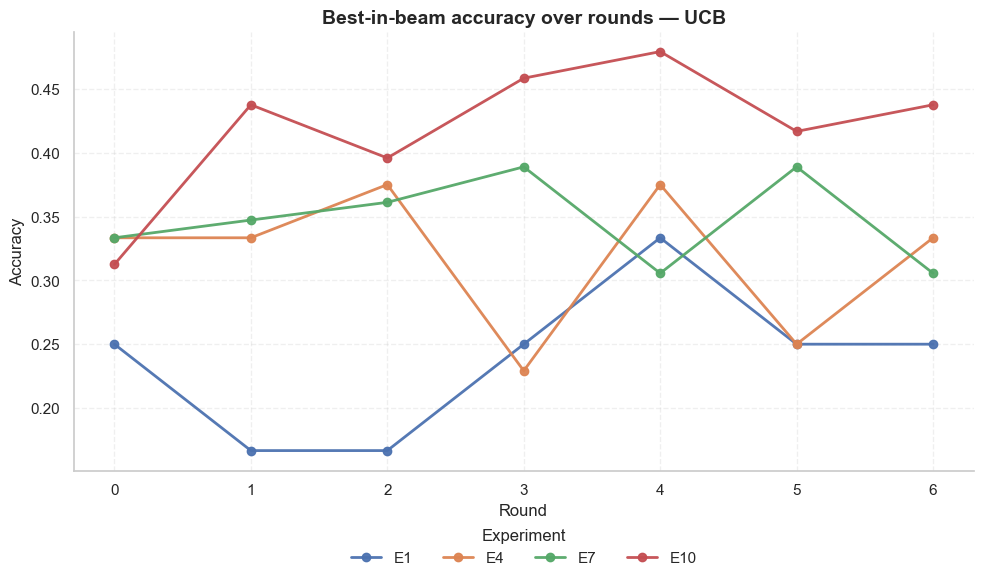

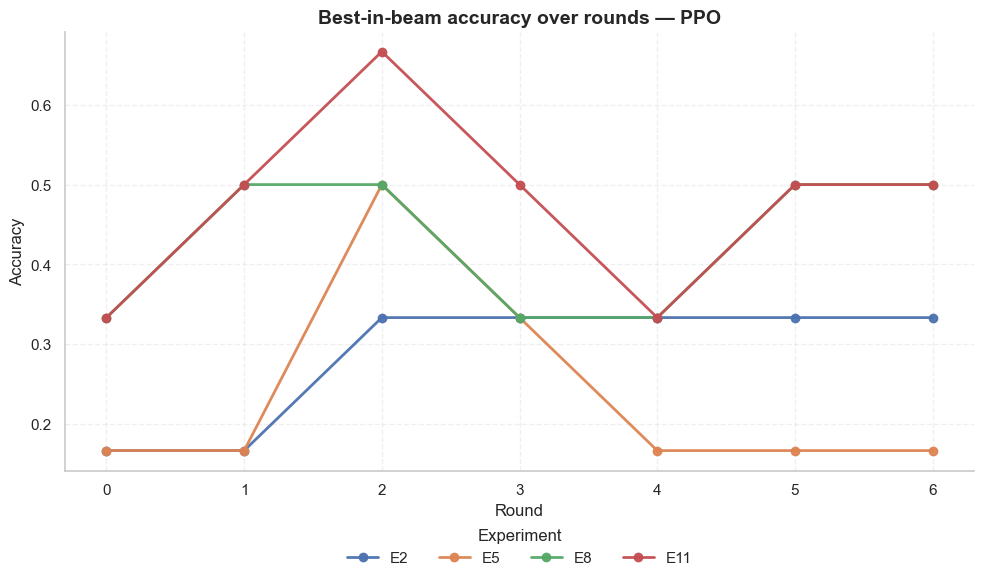

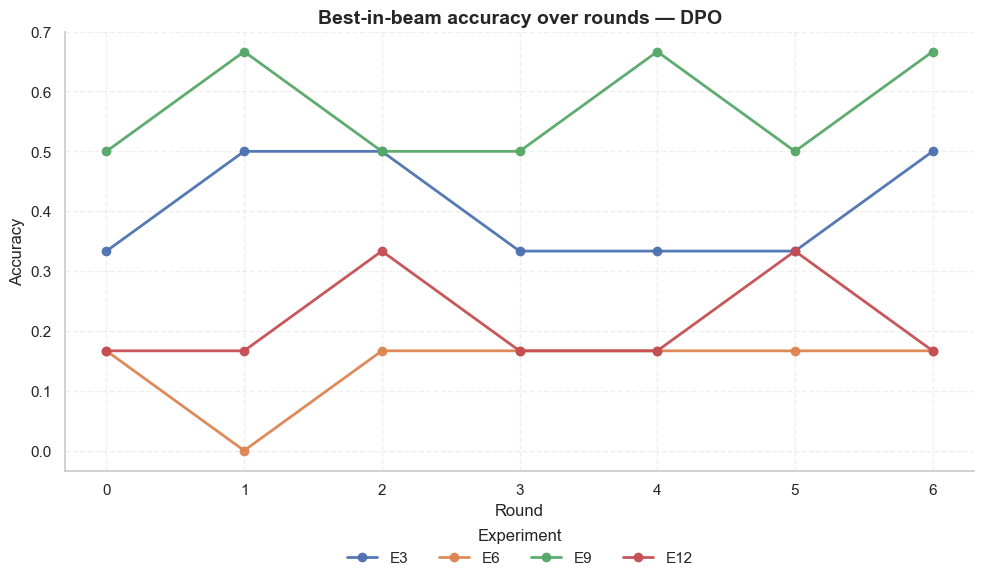

In [ ]:
def parse_runs(lines, run_starts):
    runs = {}
    for si, start in enumerate(run_starts):
        end = run_starts[si+1] if si+1 < len(run_starts) else len(lines)
        meta = json.loads(lines[start].strip())
        m = re.search(r"exp[\\/](E\d+)", meta.get("out","") or "")
        rid = m.group(1) if m else f"run_{si}"
        record = {"evaluator": meta.get("evaluator"),
                  "samples_per_eval": meta.get("samples_per_eval"),
                  "eval_rounds": meta.get("eval_rounds"),
                  "eval_prompts_per_round": meta.get("eval_prompts_per_round"),
                  "top_k": meta.get("top_k"),
                  "beam_size": meta.get("beam_size"),
                  "rounds": []}
        i = start + 1
        while i < end:
            l = lines[i].strip()
            if l.startswith("======== ROUND"):
                m2 = re.search(r"ROUND\s+(\d+)", l)
                rnum = int(m2.group(1)) if m2 else None
                # Skip time line if present
                if i+1 < end and re.match(r"([0-9]+(?:\.[0-9]+)?)s", lines[i+1].strip()):
                    i += 2
                else:
                    i += 1
                arrs = []
                while i < end and not lines[i].startswith("{") and not lines[i].startswith("======== ROUND"):
                    s = lines[i].strip()
                    if s.startswith("[") and s.endswith("]"):
                        try:
                            arrs.append(json.loads(s))
                        except Exception:
                            pass
                    i += 1
                record["rounds"].append({"round": rnum, "arrays": arrs})
                continue
            i += 1
        runs[rid] = record
    return runs

runs = parse_runs(lines, run_starts)

# Build per-run series
per_run_series = {}
for rid, rec in runs.items():
    eval_name = rec["evaluator"]
    xs, ys = [], []
    for rr in sorted(rec["rounds"], key=lambda x: x["round"] if x["round"] is not None else -1):
        arrs = rr["arrays"]
        if not arrs:
            continue
        rewards = arrs[0] if eval_name == "ucb" else (arrs[1] if len(arrs) > 1 else [])
        if not rewards:
            continue
        xs.append(rr["round"])
        ys.append(max(rewards))
    if xs:
        per_run_series[rid] = {"evaluator": eval_name, "rounds": np.array(xs), "best": np.array(ys)}

# Group runs
groups = {"ucb": [], "ppo": [], "dpo": []}
for rid, s in per_run_series.items():
    groups[s["evaluator"]].append((rid, s["rounds"], s["best"]))

# Plot per evaluator
out_paths = {}
for eval_name, series_list in groups.items():
    if not series_list:
        continue
    fig, ax = plt.subplots(figsize=(10, 6))
    series_list = sorted(series_list, key=lambda t: int(re.sub(r"\D","", t[0])))
    for rid, xs, ys in series_list:
        ax.plot(xs, ys, marker="o", linewidth=2, markersize=6, label=rid, alpha=0.95)
    ax.set_title(f"Best-in-beam accuracy over rounds — {eval_name.upper()}", fontsize=14, weight="bold")
    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.grid(True, axis="both", alpha=0.3, linestyle="--")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(title="Experiment", frameon=False, loc="upper center",
              bbox_to_anchor=(0.5, -0.10), ncol=min(4, len(series_list)))
    plt.tight_layout()
    out = Path(f"/mnt/data/dev_best_over_rounds_{eval_name}.png")
    #plt.savefig(out, dpi=200, bbox_inches="tight")
    out_paths[eval_name] = out

# Averages per round per evaluator
all_rounds = sorted(set(int(r) for s in per_run_series.values() for r in s["rounds"]))
rows = []
for r in all_rounds:
    row = {"Round": r}
    for e in ["ucb","ppo","dpo"]:
        vals = []
        for rid, xs, ys in groups.get(e, []):
            mask = (xs == r)
            if mask.any():
                vals.append(float(ys[mask][0]))
        row[f"{e.upper()}_mean"] = (sum(vals)/len(vals)) if vals else None
        row[f"{e.upper()}_n"] = len(vals)
    rows.append(row)

avg_df = pd.DataFrame(rows).sort_values("Round")
avg_csv = Path("/mnt/data/evaluator_round_means.csv")
avg_df.to_csv(avg_csv, index=False)

# from caas_jupyter_tools import display_dataframe_to_user
# display_dataframe_to_user("Average best-in-beam reward per round by evaluator", avg_df)

out_paths, avg_csv

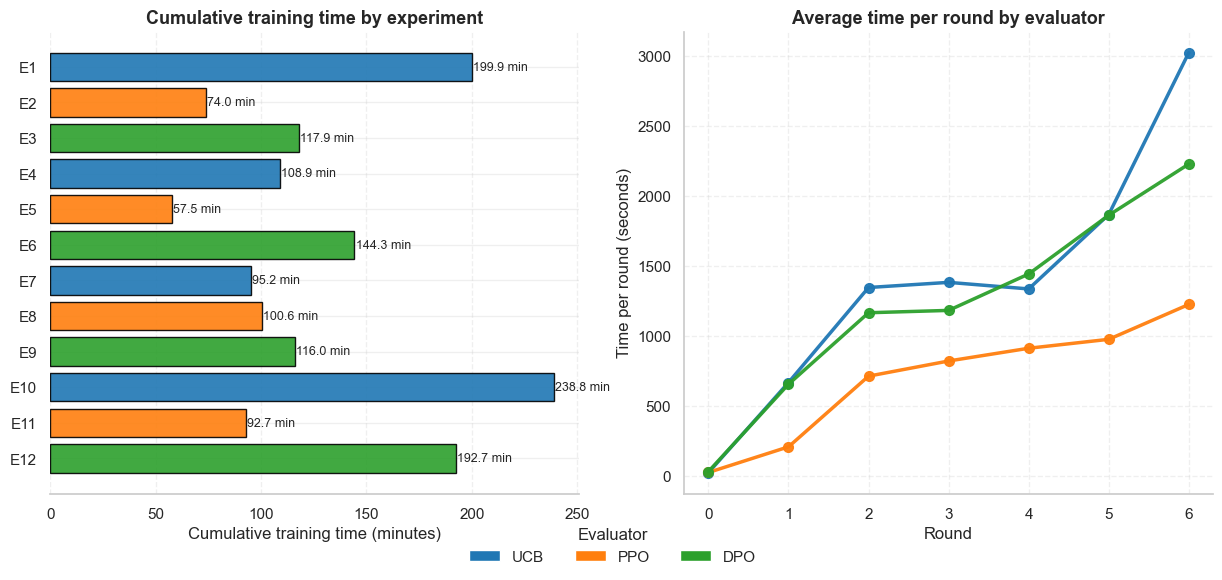

In [12]:


# -------- Load and parse logs --------
log_path = Path(r"C:\Users\cypri\Desktop\Master Thesis\exp\all logs")

lines = log_path.read_text(encoding="utf-8", errors="ignore").splitlines()

# ---- Find JSON headers robustly ----
run_starts = []
for i, l in enumerate(lines):
    s = l.strip()
    if s.startswith("{") and s.endswith("}"):
        try:
            _ = json.loads(s)
            run_starts.append(i)
        except Exception:
            pass

def parse_runs_with_times(lines, starts):
    runs = {}
    for si, start in enumerate(starts):
        end = starts[si+1] if si+1 < len(starts) else len(lines)
        meta = json.loads(lines[start].strip())
        m = re.search(r"exp[\\/](E\d+)", meta.get("out","") or "")
        rid = m.group(1) if m else f"run_{si}"
        evaluator = meta.get("evaluator")
        record = {"evaluator": evaluator, "rounds": []}
        i = start + 1
        while i < end:
            l = lines[i].strip()
            if l.startswith("======== ROUND"):
                m2 = re.search(r"ROUND\s+(\d+)", l)
                rnum = int(m2.group(1)) if m2 else None
                # time is typically next line like "213.45s"
                time_s = None
                if i+1 < end:
                    tline = lines[i+1].strip()
                    mt = re.match(r"([0-9]+(?:\.[0-9]+)?)s", tline)
                    if mt:
                        time_s = float(mt.group(1))
                        i += 2
                    else:
                        i += 1
                else:
                    i += 1
                # skip arrays
                while i < end and not lines[i].startswith("{") and not lines[i].startswith("======== ROUND"):
                    i += 1
                record["rounds"].append({"round": rnum, "time_s": time_s})
                continue
            i += 1
        runs[rid] = record
    return runs

runs = parse_runs_with_times(lines, run_starts)

# ---- Build dataframes ----
# Total time per run
totals = []
for rid, rec in runs.items():
    times = [r["time_s"] for r in rec["rounds"] if r["time_s"] is not None]
    tot_time = float(np.sum(times)) if times else 0.0
    totals.append({"Run": rid, "Evaluator": rec["evaluator"], "TotalTime_s": tot_time})

tot_df = pd.DataFrame(totals)
if not tot_df.empty:
    tot_df["RunNum"] = tot_df["Run"].str.extract(r"E(\d+)").astype(int)
    tot_df = tot_df.sort_values("RunNum")

# Average time per round by evaluator
records = []
for rid, rec in runs.items():
    eval_name = rec["evaluator"]
    for rr in rec["rounds"]:
        if rr["time_s"] is None or rr["round"] is None:
            continue
        records.append({"Evaluator": eval_name, "Round": int(rr["round"]), "Time_s": float(rr["time_s"])})

round_df = pd.DataFrame(records)
avg_df = (round_df.groupby(["Evaluator","Round"], as_index=False)["Time_s"]
                   .mean()
                   .sort_values(["Round","Evaluator"]))

# ---- Colors (consistent with prior plots) ----
color_map = {"ucb": "#1f77b4", "ppo": "#ff7f0e", "dpo": "#2ca02c"}
def eval_color(e):
    if e is None:
        return "#999999"
    return color_map.get(str(e).lower(), "#999999")

# ---- Create a single figure with two subplots side-by-side ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: cumulative time per experiment (horizontal bars)
colors = [eval_color(e) for e in tot_df["Evaluator"]]
bars = ax1.barh(tot_df["Run"], tot_df["TotalTime_s"] / 60.0, color=colors, edgecolor="black", alpha=0.9)
for bar, val_s in zip(bars, tot_df["TotalTime_s"]):
    minutes = val_s / 60.0
    y = bar.get_y() + bar.get_height()/2
    ax1.text(minutes + 0.5, y, f"{minutes:.1f} min", va="center", ha="left", fontsize=9)
ax1.set_xlabel("Cumulative training time (minutes)", fontsize=12)
ax1.set_ylabel("")
ax1.set_title("Cumulative training time by experiment", fontsize=13, weight="bold")
ax1.grid(axis="x", alpha=0.3, linestyle="--")
ax1.invert_yaxis()
for spine in ["top", "right", "left"]:
    ax1.spines[spine].set_visible(False)

# Right: average time per round by evaluator (lines)
for e in ["ucb","ppo","dpo"]:
    sub = avg_df[avg_df["Evaluator"].str.lower() == e]
    if sub.empty:
        continue
    ax2.plot(sub["Round"], sub["Time_s"], marker="o", linewidth=2.5, markersize=7,
             label=e.upper(), color=color_map[e], alpha=0.95)
ax2.set_title("Average time per round by evaluator", fontsize=13, weight="bold")
ax2.set_xlabel("Round", fontsize=12)
ax2.set_ylabel("Time per round (seconds)", fontsize=12)
ax2.grid(True, axis="both", alpha=0.3, linestyle="--")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

# Shared legend centered below both plots
legend_handles = [Patch(facecolor=color_map[k], label=k.upper()) for k in ["ucb","ppo","dpo"]]
fig.legend(handles=legend_handles, title="Evaluator", frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03))
